# Getting Started with EDA-Schema

This tutorial introduces **EDA-Schema**, a property graph data model schema designed to represent digital circuit designs and their attributes. The tutorial outlines the core features and functionalities of EDA-Schema, supplemented by hands-on examples to demonstrate its practical usage.

EDA-Schema standardizes graph structures and feature sets for digital circuits, utilizing data from the IWLS'05 benchmark circuit suite and the Skywater 130 nm Process Design Kit (PDK). The dataset includes physical designs generated using the open-source toolset OpenROAD.

This tutorial covers:
1. An introduction to EDA-Schema.
2. Techniques for working with datasets.
3. Methods for representing and analyzing digital circuits using the property graph data model.

**Note:** This notebook uses the current EDA-Schema API. Make sure you have EDA-Schema installed and a dataset available. You can create a minimal dataset using `examples/01_basics/02_create_dataset.py`.

---

## Setting Up the Environment

This section details the process of importing the required libraries and creating the dataset object necessary for utilizing EDA-Schema. These steps establish the environment and connect to the database and file system where the dataset is stored.

### Importing Libraries

The tutorial begins by importing libraries essential for data manipulation, visualization, and interaction with EDA-Schema.

In [1]:
import os
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from eda_schema.dataset import Dataset
from eda_schema.db import ParquetDB

import warnings
warnings.filterwarnings('ignore')

#### Creating the Dataset Object

The first step involves creating an instance of the `ParquetDB` class (recommended), which establishes a connection to the database and file system containing the dataset.

Subsequently, a `Dataset` object is instantiated to facilitate interaction with the dataset.

With these steps completed, the environment is configured and ready for exploring and analyzing digital circuit designs using EDA-Schema.

In [2]:
# Update this path to point to your dataset directory
# For this tutorial, you can use the minimal dataset in examples/data/minimal_dataset/
DATASET_DIR = "../../dataset/test"  # Adjust path as needed

# Initialize database and dataset
db = ParquetDB(DATASET_DIR)
dataset = Dataset(db)

# Load standard cells (if available)
dataset.load_standard_cells()
print(f"Loaded {len(dataset.standard_cells)} standard cells")

Loaded 441 standard cells


## Understanding Design Flows and Stages

EDA-Schema organizes circuit designs using a hierarchical structure:

- **Design Flow**: Represents a complete RTL-to-GDSII execution, recording metadata such as design name, PDK, and tool versions
- **Design Stage**: Each phase of the digital design process (synthesis, placement, routing, signoff)
- **Design Constraints**: Timing and physical constraints (clock period, I/O delays, max transition, etc.)

The OpenROAD flow includes these stages:
- `floorplan`: Initial floorplanning
- `global_place`: Global placement
- `place_resize`: Placement with resizing
- `detailed_place`: Detailed placement
- `cts`: Clock tree synthesis
- `global_route`: Global routing
- `detailed_route`: Detailed routing
- `final`: Final layout with filler cells

First explore what design flows and stages are available in the dataset.


In [3]:
# Explore available design flows
print("=== Available Design Flows ===")
design_flows = dataset.db.get_table_data("design_flows")
print(f"Total design flows: {len(design_flows)}")
print("\nSample design flows:")
design_flows.head()

=== Available Design Flows ===
Total design flows: 1

Sample design flows:


,flow_id,design,run_status
0,gcd-000001,gcd,Complete


In [4]:
# Explore available design stages
print("\n=== Available Design Stages ===")
design_stages = dataset.db.get_table_data("design_stages")
print(f"Total design stages: {len(design_stages)}")
print("\nStages by flow:")
stage_counts = design_stages.groupby('flow_id')['stage'].count()
print(stage_counts.head(10))

print("\nUnique stages available:")
unique_stages = design_stages['stage'].unique()
print(sorted(unique_stages))


=== Available Design Stages ===
Total design stages: 8

Stages by flow:
flow_id
gcd-000001    8
Name: stage, dtype: int64

Unique stages available:
['cts', 'detailed_place', 'detailed_route', 'final', 'floorplan', 'global_place', 'global_route', 'place_resized']


### Loading a Design Flow

A design flow represents a complete execution of the RTL-to-GDSII process. You can load a full design flow or access specific stages.


In [5]:
# Select a flow_id and stage for this tutorial
# Update these values based on your dataset
flow_id = "gcd-000001"  # Update to match your dataset
stage = "final"  # Can be: floorplan, global_place, detailed_place, cts, global_route, detailed_route, final

print(f"Selected flow_id: {flow_id}")
print(f"Selected stage: {stage}")

# Load a design flow (all stages)
design_flow = dataset.load_design_flow(flow_id=flow_id)
print(f"\n=== Design Flow: {flow_id} ===")
print(f"Available stages: {list(design_flow.stages.keys())}")

# Access a specific stage
if stage in design_flow.stages:
    print(f"\nStage '{stage}' is available in this flow")
else:
    print(f"\nStage '{stage}' not found. Available stages: {list(design_flow.stages.keys())}")


Selected flow_id: gcd-000001
Selected stage: final



=== Design Flow: gcd-000001 ===
Available stages: ['floorplan', 'global_place', 'place_resized', 'detailed_place', 'cts', 'global_route', 'detailed_route', 'final']

Stage 'final' is available in this flow


### Design Constraints

Design constraints specify timing and physical constraints for the design, such as clock period, input/output delays, and maximum transition/fanout/capacitance limits.

**Key Fields:**
- `clock_period`: Clock period constraint (in ns)
- `input_delay`: Input delay constraint (in ns)
- `output_delay`: Output delay constraint (in ns)
- `max_transition`: Maximum signal transition time (in ns)
- `max_fanout`: Maximum fanout
- `max_capacitance`: Maximum capacitance (in fF, femtoFarads)
- `core_utilization`: Target core utilization


In [6]:
# Access design constraints
constraints = dataset.db.get_entity("constraints", flow_id=flow_id)
print("=== Design Constraints ===")
print(f"Clock period: {constraints.clock_period} ns" if constraints.clock_period is not None else "Clock period: Not specified")
print(f"Clock uncertainty: {constraints.clock_uncertainty} ns" if constraints.clock_uncertainty is not None else "Clock uncertainty: Not specified")
print(f"Clock latency: {constraints.clock_latency} ns" if constraints.clock_latency is not None else "Clock latency: Not specified")
print(f"Clock transition: {constraints.clock_transition} ns" if constraints.clock_transition is not None else "Clock transition: Not specified")
print(f"Input delay: {constraints.input_delay} ns" if constraints.input_delay is not None else "Input delay: Not specified")
print(f"Output delay: {constraints.output_delay} ns" if constraints.output_delay is not None else "Output delay: Not specified")
print(f"Aspect ratio: {constraints.aspect_ratio}" if constraints.aspect_ratio is not None else "Aspect ratio: Not specified")
print(f"Core utilization: {constraints.core_utilization}" if constraints.core_utilization is not None else "Core utilization: Not specified")

=== Design Constraints ===
Clock period: 3.0 ns
Clock uncertainty: 0.05 ns
Clock latency: 0.03 ns
Clock transition: 0.02 ns
Input delay: 0.03 ns
Output delay: 0.03 ns
Aspect ratio: 1.0
Core utilization: 0.3


### Loading a Netlist

A netlist is identified by `flow_id` (design flow identifier) and `stage` (design stage). It can be loaded from the database into an EDA-schema netlist graph object to extract specific details about the digital circuit. A snapshot of the netlist can be extracted in the following design stages:

- Post floorplan: `floorplan`
- Post global placement: `global_place`
- Post detailed placement: `detailed_place`
- Post CTS: `cts`
- Post global routing: `global_route`
- Post detailed routing: `detailed_route`
- Final routed design: `final`

In [7]:
# Load the netlist for the selected flow_id and stage
netlist = dataset.load_netlist(flow_id=flow_id, stage=stage)
print(f"Loaded netlist for flow '{flow_id}' at stage '{stage}'")
print(f"Netlist has {netlist.no_of_cells} cells and {netlist.no_of_nets} nets")

Loaded netlist for flow 'gcd-000001' at stage 'final'
Netlist has 1105 cells and 413 nets


Once the netlist is loaded, various attributes can be accessed to get detailed information about the digital circuit.

- **Width**: The width of the circuit.
- **Height**: The height of the circuit.
- **Number of inputs**: The number of input pins in the circuit.
- **Number of outputs**: The number of output pins in the circuit.
- **Number of cells**: The number of cells in the circuit.
- **Number of nets**: The number of nets (connections) in the circuit.
- **Number of pins**: The number of pins in the circuit.
- **Utilization**: The utilization ratio of the design.

These attributes provide a comprehensive overview of the circuit's physical and structural properties, enabling further analysis and optimization.

In [8]:
print("Width:", netlist.width)
print("Height:", netlist.height)
print("Number of inputs:", netlist.no_of_inputs)
print("Number of outputs:", netlist.no_of_outputs)
print("Number of cells:", netlist.no_of_cells)
print("Number of nets:", netlist.no_of_nets)
print("Number of pins:", netlist.no_of_pins)
print("Utilization:", netlist.utilization)

Width: 97.34
Height: 97.34
Number of inputs: 36
Number of outputs: 18
Number of cells: 1105
Number of nets: 413
Number of pins: 1081
Utilization: 0.98


### Exploring Netlist Graph Entities

A netlist graph in EDA-schema includes inputs, outputs, gates, and interconnects. Each entity type provides specific details about the digital circuit's structure and properties. It can be iterated to access and analyze individual circuit components.

In [9]:
# Iterate through all nodes in the netlist
print(f"Total nodes in netlist: {len(netlist.nodes)}")
print("\nFirst 20 nodes:")
for i, node in enumerate(netlist.nodes):
    if i >= 20:
        print(f"... and {len(netlist.nodes) - 20} more nodes")
        break
    node_type = netlist.nodes[node].get('type', 'UNKNOWN')
    print(f"  {node} (Type: {node_type})")

Total nodes in netlist: 2653

First 20 nodes:
  clk_input (Type: PORT)
  clk (Type: NET)
  req_msg_0__input (Type: PORT)
  req_msg_0_ (Type: NET)
  req_msg_10__input (Type: PORT)
  req_msg_10_ (Type: NET)
  req_msg_11__input (Type: PORT)
  req_msg_11_ (Type: NET)
  req_msg_12__input (Type: PORT)
  req_msg_12_ (Type: NET)
  req_msg_13__input (Type: PORT)
  req_msg_13_ (Type: NET)
  req_msg_14__input (Type: PORT)
  req_msg_14_ (Type: NET)
  req_msg_15__input (Type: PORT)
  req_msg_15_ (Type: NET)
  req_msg_16__input (Type: PORT)
  req_msg_16_ (Type: NET)
  req_msg_17__input (Type: PORT)
  req_msg_17_ (Type: NET)
... and 2633 more nodes



#### Input Entity

An input entity represents an input pin of the circuit. Here is an example of how to access and print details of an input entity:
- **Input name**: Name of the input pin.
- **Direction**: Direction of the signal (input).
- **Coordinate**: (x, y) position of the input pin.
- **Capacitance**: Capacitance of the input pin (in fF, femtoFarads).


In [10]:
# Find an input port node
port_nodes = [n for n in netlist.nodes if netlist.nodes[n].get('type') == 'PORT']
input_nodes = [n for n in port_nodes if netlist.nodes[n].get('entity') and 
               hasattr(netlist.nodes[n]['entity'], 'direction') and
               netlist.nodes[n]['entity'].direction == 'INPUT']

input_name = input_nodes[0]
input_entity = netlist.nodes[input_name]["entity"]
print("Input name:", input_entity.name)
print("Direction:", input_entity.direction)
print("Coordinates (x, y):", input_entity.x, input_entity.y)

Input name: clk_input
Direction: INPUT
Coordinates (x, y): 0.4 81.94


#### Output Entity

An output entity represents an output pin of the circuit. Here is an example of how to access and print details of an output entity:

- **Output name**: Name of the output pin.
- **Direction**: Direction of the signal (output).
- **Coordinate**: (x, y) position of the output pin.
- **Capacitance**: Capacitance of the output pin (in fF, femtoFarads).


In [11]:
# Find an output port node
port_nodes = [n for n in netlist.nodes if netlist.nodes[n].get('type') == 'PORT']
output_nodes = [n for n in port_nodes if netlist.nodes[n].get('entity') and 
                hasattr(netlist.nodes[n]['entity'], 'direction') and
                netlist.nodes[n]['entity'].direction == 'OUTPUT']

output_name = output_nodes[0]
output_entity = netlist.nodes[output_name]["entity"]
print("Output name:", output_entity.name)
print("Direction:", output_entity.direction)
print("Coordinates (x, y):", f"({output_entity.x}, {output_entity.y})")

Output name: req_rdy_output
Direction: OUTPUT
Coordinates (x, y): (96.94, 13.94)


#### Gate Entity

A gate entity represents a logic gate in the circuit. Here is an example of how to access and print details of a gate entity:

- **Gate name**: Name of the gate.
- **Standard Cell**: Type of standard cell used for the gate.
- **Bounding box**: (x_min, y_min) to (x_max, y_max) position of the gate.
- **Number of inputs/outputs**: Count of input and output connections.

In [12]:
# Get first gate node
gate_nodes = [n for n in netlist.nodes if netlist.nodes[n].get('type') == 'GATE']
gate_name = gate_nodes[0]
gate_entity = netlist.nodes[gate_name]["entity"]
print("Gate name:", gate_entity.name)
print("Standard Cell:", gate_entity.standard_cell)
print("Bounding box:", f"({gate_entity.x_min}, {gate_entity.y_min}) to ({gate_entity.x_max}, {gate_entity.y_max})")
print("No. of inputs:", gate_entity.no_of_inputs)
print("No. of outputs:", gate_entity.no_of_outputs)

Gate name: FILLER_0_0_0
Standard Cell: sky130_fd_sc_hd__fill_8
Bounding box: (5.06, 5.44) to (8.74, 8.16)
No. of inputs: 0
No. of outputs: 0


#### Standard Cell Library

Standard cells are the basic building blocks of digital designs. Each gate in the design references a standard cell from the library. Standard cell information includes cell characteristics like area, power, timing arcs, and pin configurations.


In [13]:
# Access standard cell library
print("=== Standard Cell Library ===")
print(f"Total standard cells: {len(dataset.standard_cells)}")

# Show sample standard cells
print("\nSample standard cells:")
sample_cells = list(dataset.standard_cells.items())[:3]
for cell_name, cell_entity in sample_cells:
    print(f"\n  Cell: {cell_name}")
    print(f"    Area: {cell_entity.width * cell_entity.height} um²" if cell_entity.width and cell_entity.height else "    Area: Not specified")
    print(f"    Number of inputs: {cell_entity.no_of_input_pins}")
    print(f"    Number of outputs: {cell_entity.no_of_output_pins}")
    print(f"    Is sequential: {cell_entity.is_sequential}")
    print(f"    Is buffer: {cell_entity.is_buffer}")
    print(f"    Is inverter: {cell_entity.is_inverter}")

# Access a specific standard cell (e.g., from a gate)
if netlist.nodes:
    for node_id, node_data in netlist.nodes.items():
        if node_data.get("type") == "GATE":
            gate_entity = node_data.get("entity")
            if gate_entity and gate_entity.standard_cell:
                std_cell_name = gate_entity.standard_cell
                if std_cell_name in dataset.standard_cells:
                    std_cell = dataset.standard_cells[std_cell_name]
                    print(f"\n=== Standard Cell for Gate '{gate_entity.name}' ===")
                    print(f"Cell name: {std_cell.name}")
                    print(
                        f"Area: {std_cell.width * std_cell.height} um²"
                        if std_cell.width and std_cell.height
                        else "Area: Not specified"
                    )
                    print(f"Inputs: {std_cell.no_of_input_pins}, Outputs: {std_cell.no_of_output_pins}")
                    break

=== Standard Cell Library ===
Total standard cells: 441

Sample standard cells:

  Cell: sky130_ef_sc_hd__decap_12
    Area: 15.0144 um²
    Number of inputs: 4
    Number of outputs: 0
    Is sequential: False
    Is buffer: False
    Is inverter: False

  Cell: sky130_ef_sc_hd__fakediode_2
    Area: 2.5024 um²
    Number of inputs: 1
    Number of outputs: 0
    Is sequential: False
    Is buffer: False
    Is inverter: False

  Cell: sky130_ef_sc_hd__fill_8
    Area: 10.0096 um²
    Number of inputs: 0
    Number of outputs: 0
    Is sequential: False
    Is buffer: False
    Is inverter: False

=== Standard Cell for Gate 'FILLER_0_0_0' ===
Cell name: sky130_fd_sc_hd__fill_8
Area: 10.0096 um²
Inputs: 0, Outputs: 0


#### Net Entity

A net entity represents an interconnect between components in the circuit. Here is an example of how to access and print details of a net entity:

- **Net name**: Name of the net.
- **Half Perimeter Wirelength (HPWL)**: Measure of the net's wirelength.
- **Bounding box**: Coordinates defining the net's bounding box.
- **Number of inputs/outputs**: Count of input and output connections.

In [14]:
# Get first net node
net_nodes = [n for n in netlist.nodes if netlist.nodes[n].get('type') == 'NET']
net_name = net_nodes[0]
net_entity = netlist.nodes[net_name]["entity"]
print("Net name:", net_name)
print("Is special net:", net_entity.is_special_net)
print("Interconnect Length:", net_entity.length)
print("Bounding box:", f"({net_entity.x_min}, {net_entity.y_min}) to ({net_entity.x_max}, {net_entity.y_max})")
print("No. of fanouts:", net_entity.no_of_fanouts)

Net name: clk
Is special net: False
Interconnect Length: 81320.0
Bounding box: (0.46, 47.94) to (47.61, 81.94)
No. of fanouts: 1


#### Netlist Images

Netlists contain Image2D visualizations of placement, routing, and pin locations as two-dimensional binary spatial maps.

**Placement Images:**
- `cell_placement`: Overall cell placement mask
- `cell_placement_combinational`: Combinational cell placement
- `cell_placement_sequential`: Sequential cell placement  
- `cell_placement_filler`: Filler cell placement

**Routing Images:**
- `routing`: Overall routing visualization
- `routing_by_metal`: Dictionary of routing per metal layer (M1, M2, M3, etc.)

**Other Images:**
- `pin_placement`: Pin location visualization

**Image Resolution:** Each pixel corresponds to a square physical region with side length equal to λ (the minimum width of metal 1 for the given PDK). The resolution is (L/λ, W/λ), where L and W are the layout length and width. This ensures consistent physical scaling across different technology nodes.

visualize all available netlist images.

=== Netlist Images ===
Total available images: 9
  Cell Placement
  Combinational Cell Placement
  Sequential Cell Placement
  Filler Cell Placement
  Pin Placement
  Routing
  Routing - met1
  Routing - met2
  Routing - met3


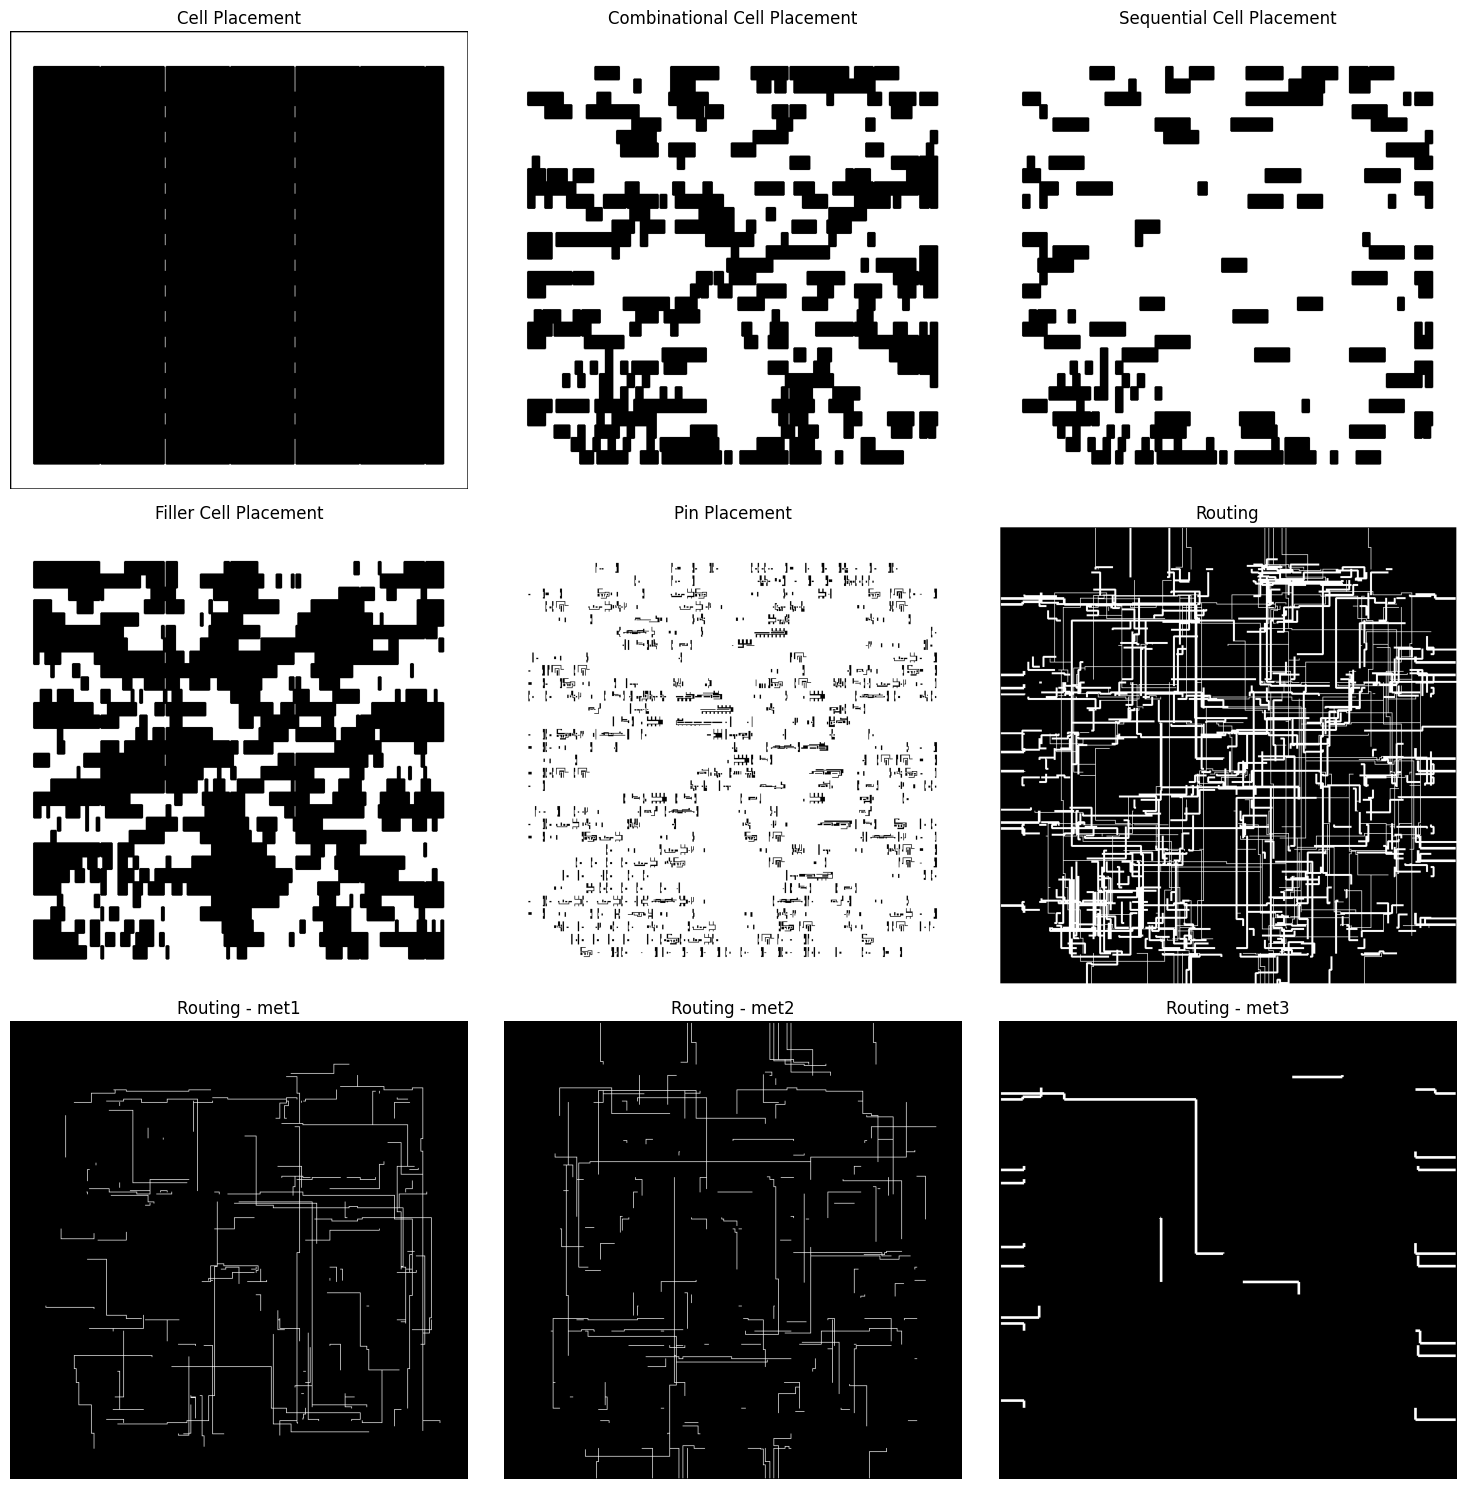


Visualized 9 netlist image(s)


In [15]:
# Visualize all available netlist images
available_images = []

# Collect all available images
image_configs = [
    ('cell_placement', 'Cell Placement'),
    ('cell_placement_combinational', 'Combinational Cell Placement'),
    ('cell_placement_sequential', 'Sequential Cell Placement'),
    ('cell_placement_filler', 'Filler Cell Placement'),
    ('pin_placement', 'Pin Placement'),
    ('routing', 'Routing'),
]

for attr, title in image_configs:
    if hasattr(netlist, attr):
        img = getattr(netlist, attr)
        if img is not None:
            available_images.append((attr, title, img))

# Add routing_by_metal layers
if netlist.routing_by_metal:
    for metal_layer, routing_img in netlist.routing_by_metal.items():
        if routing_img is not None:
            available_images.append((f'routing_by_metal[{metal_layer}]', f'Routing - {metal_layer}', routing_img))

# Display summary
print(f"=== Netlist Images ===")
print(f"Total available images: {len(available_images)}")
for attr, title, _ in available_images:
    print(f"  {title}")

# Visualize images in a grid
if available_images:
    # Calculate grid size (prefer 3 columns)
    n_images = len(available_images)
    cols = 3
    rows = (n_images + cols - 1) // cols  # Ceiling division
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    # Ensure axes is always a flat numpy array we can index
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    for idx, (attr, title, img) in enumerate(available_images):
        ax = axes[idx]
        # Use invert_mask for placement images, not for routing
        if 'placement' in attr.lower():
            img.plot(ax=ax, title=title, invert_mask=True)
        else:
            img.plot(ax=ax, title=title)
    
    # Hide unused subplots
    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nVisualized {n_images} netlist image(s)")
else:
    print("\nNo netlist images available for this stage")
    print("Note: Images are typically available after placement and routing stages")

The interconnect entity in a netlist graph is composed of interconnect nodes, each representing a segment of the connection between components in the circuit.
To retrieve and display information about the interconnect nodes, the `net_entity.nodes` dictionary is iterated over, and details of each node are collected into a DataFrame.
The resulting DataFrame provides a detailed view of each interconnect node, showing the following attributes:

- **length**: The length of the interconnect segment.
- **x1, y1**: The starting coordinates of the interconnect segment.
- **x2, y2**: The ending coordinates of the interconnect segment.
- **x, y**: The coordinates of the interconnect node.

### Netlist Quality Metrics

Each design stage has associated quality metrics that provide detailed information about its performance, area, power consumption, and timing. These metrics are accessed through the `DesignStageEntity`. The following sections show how to access and print these metrics.

#### Loading Design Stage

First, load the complete design stage which includes all metrics:

In [16]:
# Load the complete design stage to access metrics
design_stage = dataset.load_design_stage(flow_id=flow_id, stage=stage)

# Access area metrics
print("=== Area Metrics ===")
print("Combinational cell area:", design_stage.area_metrics.combinational_cell_area)
print("Sequential cell area:", design_stage.area_metrics.sequential_cell_area)
print("Buffer area:", design_stage.area_metrics.buffer_area)
print("Inverter area:", design_stage.area_metrics.inverter_area)
print("Macro area:", design_stage.area_metrics.macro_area)
print("Cell area:", design_stage.area_metrics.cell_area)
print("Total area:", design_stage.area_metrics.total_area)

=== Area Metrics ===
Combinational cell area: 6577.5584
Sequential cell area: 753.2224
Buffer area: 759.4784
Inverter area: 75.072
Macro area: 0.0
Cell area: 7330.7808
Total area: 7207.0


#### Power Metrics

The power metrics provide information about the power consumption of various components in the circuit. All power values are in **μW (microwatts)**.

In [17]:
# Access power metrics
print("=== Power Metrics ===")
print("Combinational power:", design_stage.power_metrics.combinational_power, "μW")
print("Sequential power:", design_stage.power_metrics.sequential_power, "μW")
print("Macro power:", design_stage.power_metrics.macro_power, "μW")
print("Internal power:", design_stage.power_metrics.internal_power, "μW")
print("Switching power:", design_stage.power_metrics.switching_power, "μW")
print("Leakage power:", design_stage.power_metrics.leakage_power, "μW")
print("Total power:", design_stage.power_metrics.total_power, "μW")

=== Power Metrics ===
Combinational power: 979.0 μW
Sequential power: 625.0 μW
Macro power: 0.0 μW
Internal power: 1190.0 μW
Switching power: 651.0 μW
Leakage power: 0.00143 μW
Total power: 1840.0 μW


#### Cell Metrics

The cell metrics provide information about the number and types of cells used in the circuit.

In [18]:
# Access cell metrics
print("=== Cell Metrics ===")
print("Number of combinational cells:", design_stage.cell_metrics.no_of_combinational_cells)
print("Number of sequential cells:", design_stage.cell_metrics.no_of_sequential_cells)
print("Number of buffers:", design_stage.cell_metrics.no_of_buffers)
print("Number of inverters:", design_stage.cell_metrics.no_of_inverters)
print("Number of fillers:", design_stage.cell_metrics.no_of_fillers)
print("Number of macros:", design_stage.cell_metrics.no_of_macros)
print("Number of total cells:", design_stage.cell_metrics.no_of_total_cells)

=== Cell Metrics ===
Number of combinational cells: 1064
Number of sequential cells: 41
Number of buffers: 126
Number of inverters: 20
Number of fillers: 652
Number of macros: 0
Number of total cells: 1105


#### Timing Metrics

The timing metrics provide information about the timing performance of the circuit, highlighting the longest path delays and potential timing violations.

#### Routability Metrics

Routability metrics describe routing demand and congestion characteristics using Rectangular Uniform wire DensitY (RUDY) maps. RUDY estimates routing demand by uniformly distributing net bounding-box contributions across the layout.

**RUDY Types:**
- `rudy_net`: Overall net-based congestion
- `rudy_net_long`: Long-range net congestion (nets spanning multiple tiles)
- `rudy_net_short`: Short-range net congestion (local nets)
- `rudy_pin`: Pin-based congestion
- `rudy_pin_long`: Long-range pin congestion
- `rudy_pin_short`: Short-range pin congestion

**Image Resolution:** RUDY maps are stored as scalar-valued spatial maps. Each pixel corresponds to a square physical region of size k×λ by k×λ, where λ is the minimum width of metal 1 and k is a downsampling factor (typically k=50). The resolution is (L/(kλ), W/(kλ)), where L and W are layout dimensions. This coarser resolution reflects the spatial aggregation used in routing demand analysis.


=== Routability Metrics ===
  rudy_net: Net-based Congestion (shape: (14, 14))
  rudy_net_long: Long Net Congestion (shape: (14, 14))
  rudy_net_short: Short Net Congestion (shape: (14, 14))
  rudy_pin: Pin-based Congestion (shape: (14, 14))
  rudy_pin_long: Long Pin Congestion (shape: (14, 14))
  rudy_pin_short: Not available


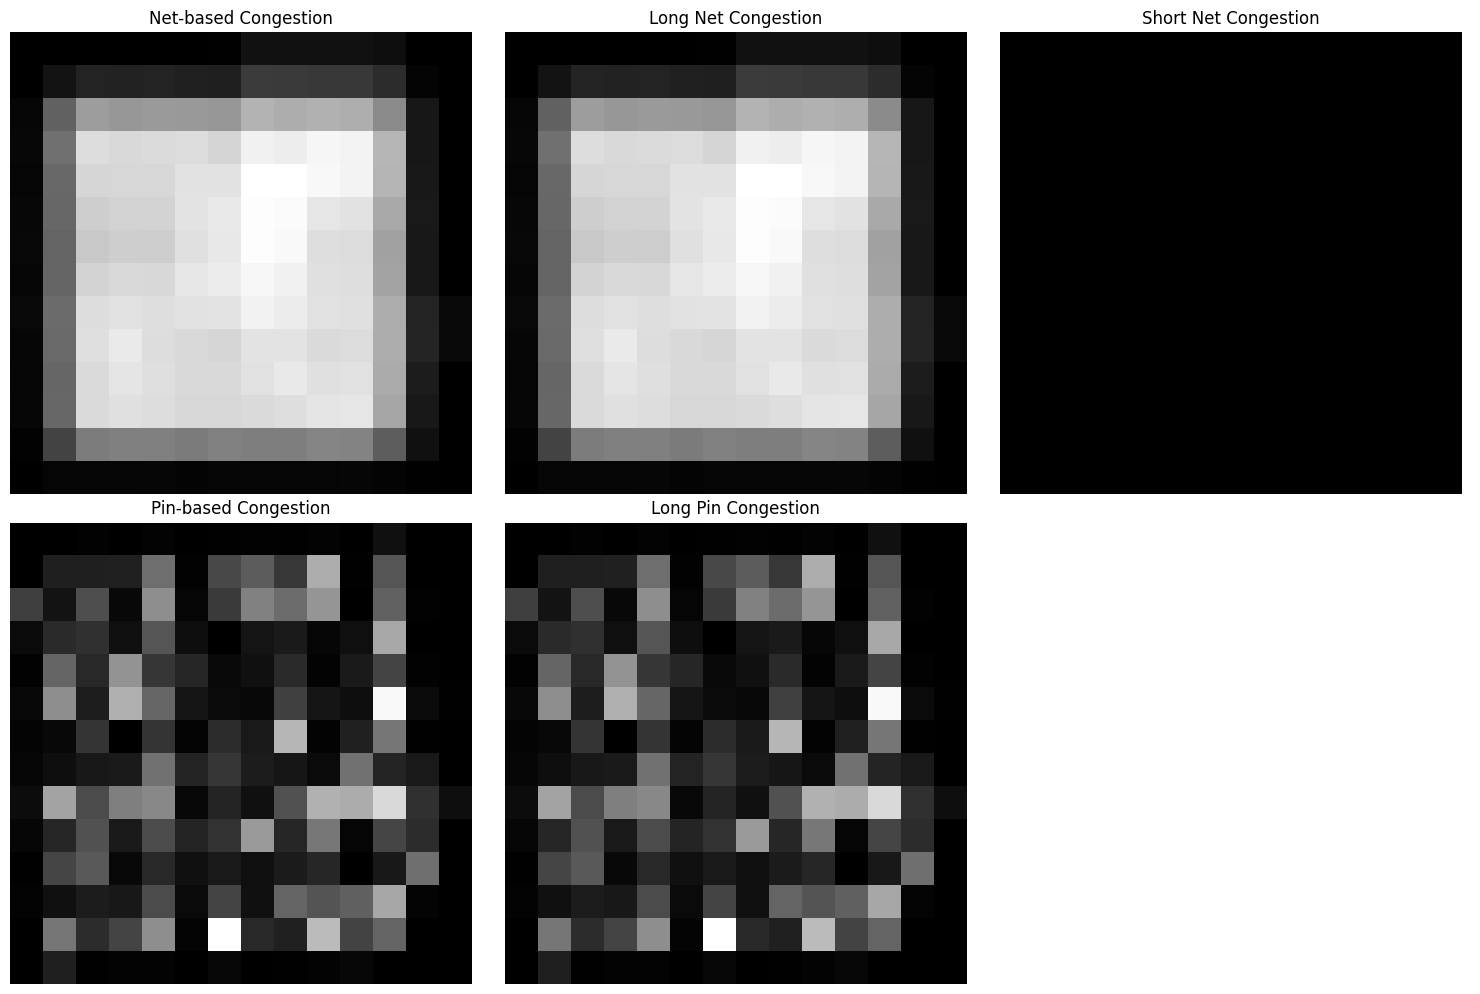


Visualized 5 RUDY image(s)


In [19]:
# Access and visualize all routability metrics
print("=== Routability Metrics ===")

# Collect all available RUDY images
rudy_types = [
    ('rudy_net', 'Net-based Congestion'),
    ('rudy_net_long', 'Long Net Congestion'),
    ('rudy_net_short', 'Short Net Congestion'),
    ('rudy_pin', 'Pin-based Congestion'),
    ('rudy_pin_long', 'Long Pin Congestion'),
    ('rudy_pin_short', 'Short Pin Congestion'),
]

available_images = []
for attr, title in rudy_types:
    if hasattr(design_stage.routability_metrics, attr):
        rudy_img = getattr(design_stage.routability_metrics, attr)
        if rudy_img is not None:
            available_images.append((attr, title, rudy_img))
            print(f"  {attr}: {title} (shape: {rudy_img.shape})")
        else:
            print(f"  {attr}: Not available")
    else:
        print(f"  {attr}: Not available")

# Visualize all available RUDY images
if available_images:
    n_images = len(available_images)
    cols = 3
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    # Ensure axes is always a flat numpy array we can index
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    for idx, (attr, title, img) in enumerate(available_images):
        ax = axes[idx]
        img.plot(ax=ax, title=title)
    
    # Hide unused subplots
    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nVisualized {n_images} RUDY image(s)")
else:
    print("\nNo RUDY images available")

In [20]:
# Access timing metrics
print("=== Timing Metrics ===")
print("Critical path startpoint:", design_stage.timing_metrics.critical_path_startpoint)
print("Critical path endpoint:", design_stage.timing_metrics.critical_path_endpoint)
print("Worst arrival time:", design_stage.timing_metrics.worst_arrival_time, "ns" if hasattr(design_stage.timing_metrics, 'worst_arrival_time') else "")
print("Worst slack:", design_stage.timing_metrics.worst_slack, "ns")
print("Total negative slack:", design_stage.timing_metrics.total_negative_slack, "ns")
print("Number of endpoints:", design_stage.timing_metrics.no_of_endpoints)
print("Number of violating endpoints:", design_stage.timing_metrics.no_of_violating_endpoints)

=== Timing Metrics ===
Critical path startpoint: _381_/Q
Critical path endpoint: _395_/D
Worst arrival time: 2.959 ns
Worst slack: -0.2732 ns
Total negative slack: -12.472615 ns
Number of endpoints: 137
Number of violating endpoints: 96


### Timing Path Entities

Netlist also includes a dictionary of timing path entities, where each key is a tuple consisting of the start and end points of a timing path. This provides detailed information about the timing performance of specific paths in the circuit.

#### Accessing a Timing Path Entity

To access a specific timing path entity, the start and end points of the timing path are used as keys in the `timing_paths` dictionary. Here is how to retrieve and print details of a timing path entity:

- **Startpoint**: The starting point of the timing path.
- **Endpoint**: The ending point of the timing path.
- **Path Type**: The type of the timing path (e.g., setup, hold).
- **Arrival Time**: The arrival time of the signal at the endpoint.
- **Required Time**: The required arrival time for the signal to meet the timing constraints.
- **Slack**: The difference between the required time and the actual arrival time (positive slack indicates the path meets timing requirements).
- **Number of gates**: The number of gates along the timing path.
- **Is critical path**: Indicates if this timing path is the critical path (the longest path in terms of delay).

In [21]:
# Access timing paths from netlist
# Note: Timing paths need to be loaded separately if not already loaded
# Load timing paths if not already loaded
timing_paths = dataset.load_timing_paths(flow_id=flow_id, stage=stage, netlist_entity=netlist)
netlist.timing_paths = timing_paths

# Get first timing path
path_key = list(netlist.timing_paths.keys())[0]
timing_path_entity = netlist.timing_paths[path_key]

print("=== Timing Path Information ===")
print("Startpoint:", timing_path_entity.startpoint)
print("Endpoint:", timing_path_entity.endpoint)
print("Path Type:", timing_path_entity.path_type)
print("Arrival Time:", timing_path_entity.arrival_time, "ns")
print("Required Time:", timing_path_entity.required_time, "ns")
print("Slack:", timing_path_entity.slack, "ns")
print("Number of pins:", timing_path_entity.no_of_pins)
print("Is critical path:", timing_path_entity.is_critical_path)

# Count net arcs and cell arcs from graph nodes
net_arc_nodes = [n for n in timing_path_entity.nodes 
                if timing_path_entity.nodes[n].get('type') == 'NET_ARC']
cell_arc_nodes = [n for n in timing_path_entity.nodes 
                 if timing_path_entity.nodes[n].get('type') == 'CELL_ARC']

print("Number of net arcs:", len(net_arc_nodes))
print("Number of cell arcs:", len(cell_arc_nodes))
print(f"Total nodes in timing path: {len(timing_path_entity.nodes)}")

=== Timing Path Information ===
Startpoint: req_msg_20_
Endpoint: _401_/D
Path Type: hold
Arrival Time: 0.4159 ns
Required Time: 0.1677 ns
Slack: 0.2482 ns
Number of pins: 8
Is critical path: False
Number of net arcs: 4
Number of cell arcs: 4
Total nodes in timing path: 16


### Timing Path Graph Structure

A timing path is represented as a directed graph TPG = (V, E), where nodes v ∈ V correspond to:
- **Pins (P)**: Input/output terminals of gates
- **I/O Ports (IO)**: External interface ports
- **Cell Timing Arcs (GA)**: Delay and slew propagation through logic elements (gate delay)
- **Net Timing Arcs (NA)**: Interconnect delay between driving pin and receiving pins (wire delay)

Edges e ∈ E represent signal propagation between successive path elements. This structure separates gate delays (cell arcs) from interconnect delays (net arcs), reflecting how static timing analysis (STA) evaluates timing paths.

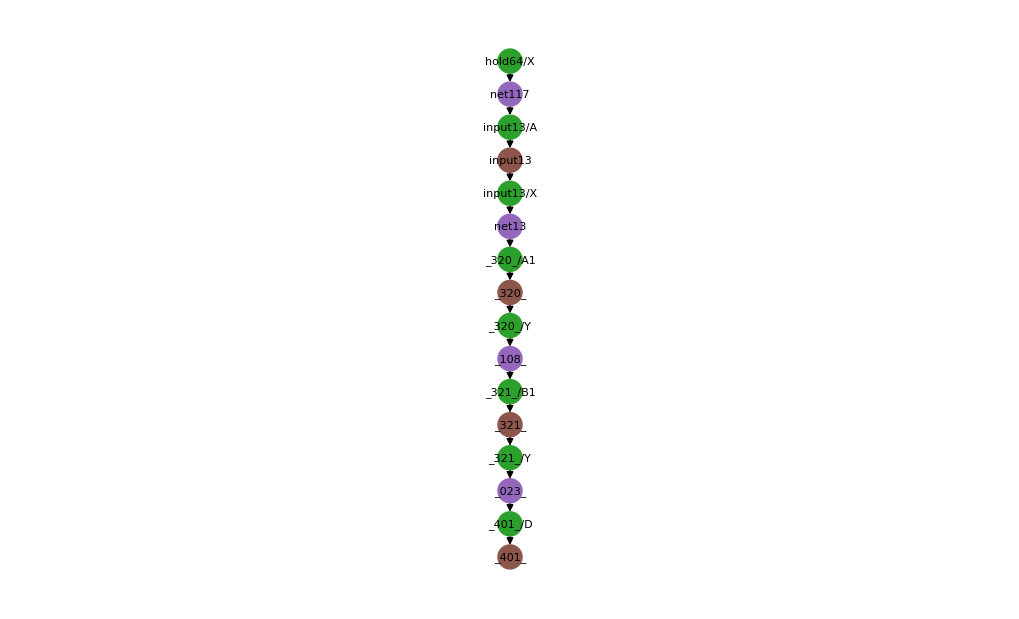

In [22]:
plt.figure(figsize=(10, 6))
timing_path_entity.plot()

#### Accessing Timing Path Components

Timing paths contain different node types that can be accessed and analyzed:

- **Pins**: Terminal points with arrival time (ns), slew (ns), slack (ns), and load capacitance (fF) information
- **Cell Arcs**: Gate delays with delay (ns), arrival time (ns), and slew (ns) through logic elements
- **Net Arcs**: Wire delays with delay (ns), arrival time (ns), slew (ns), and capacitance (fF) for interconnects
- **I/O Ports**: External interface points

examine the different components of a timing path.

In [23]:
from IPython.display import display

# Analyze timing path components
print("=== Timing Path Components ===")

# Separate nodes by type
pins = []
cell_arcs = []
net_arcs = []
ports = []

for node in timing_path_entity.nodes:
    node_data = timing_path_entity.nodes[node]
    node_type = node_data.get("type", "UNKNOWN")

    if "entity" in node_data:
        entity = node_data["entity"]
        entity_data = entity.get_tabular_data()
        entity_data["name"] = node
        entity_data["node_type"] = node_type

        if node_type == "PIN":
            pins.append(entity_data)
        elif node_type == "CELL_ARC":
            cell_arcs.append(entity_data)
        elif node_type == "NET_ARC":
            net_arcs.append(entity_data)
        elif node_type == "PORT":
            ports.append(entity_data)

print(f"Total nodes: {len(timing_path_entity.nodes)}")
print(f"  Pins: {len(pins)}")
print(f"  Cell Arcs (gate delays): {len(cell_arcs)}")
print(f"  Net Arcs (wire delays): {len(net_arcs)}")
print(f"  Ports: {len(ports)}")

# Display sample cell arcs (gate delays)
if cell_arcs:
    print("\n=== Sample Cell Arcs (Gate Delays) ===")
    cell_arcs_df = pd.DataFrame(cell_arcs).set_index("name")
    display(cell_arcs_df[["gate_name", "delay", "arrival_time", "slew"]].head())

# Display sample net arcs (wire delays)
if net_arcs:
    print("\n=== Sample Net Arcs (Wire Delays) ===")
    net_arcs_df = pd.DataFrame(net_arcs).set_index("name")
    display(net_arcs_df[["net_name", "delay", "arrival_time", "slew", "capacitance"]].head())

# Display sample pins
if pins:
    print("\n=== Sample Pins ===")
    pins_df = pd.DataFrame(pins).set_index("name")
    display(pins_df.head())


=== Timing Path Components ===
Total nodes: 16
  Pins: 8
  Cell Arcs (gate delays): 4
  Net Arcs (wire delays): 4
  Ports: 0

=== Sample Cell Arcs (Gate Delays) ===


,gate_name,delay,arrival_time,slew
name,,,,
input13,input13,0.0001,0.1901,0.03522
_320_,_320_,0.0001,0.2717,0.04988
_321_,_321_,0.0000,0.3421,0.05216
_401_,_401_,0.0001,0.4159,0.06916



=== Sample Net Arcs (Wire Delays) ===


,net_name,delay,arrival_time,slew,capacitance
name,,,,,
net117,net117,0.1900,0.1900,0.03522,2.463
net13,net13,0.0815,0.2716,0.04988,3.337
_108_,_108_,0.0704,0.3421,0.05216,2.408
_023_,_023_,0.0737,0.4158,0.06916,3.069



=== Sample Pins ===


,flow_id,stage,direction,is_startpoint,is_endpoint,x_min,y_min,x_max,y_max,setup_rise_slew,setup_fall_slew,hold_rise_slew,hold_fall_slew,setup_rise_slack,setup_fall_slack,hold_rise_slack,hold_fall_slack,load_capacitance,switching_activity,node_type
name,,,,,,,,,,,,,,,,,,,,
hold64/X,gcd-000001,final,driver,False,False,91.530,30.175,32.385,91.910,0.034048,0.030857,0.034048,0.030857,2.336999,2.194911,0.210898,0.335624,0.000000,33333300.0,PIN
input13/A,gcd-000001,final,sink,False,False,91.565,33.625,33.995,91.895,0.034048,0.030857,0.034048,0.030857,2.336999,2.194911,0.210898,0.335624,0.002186,33333300.0,PIN
input13/X,gcd-000001,final,driver,False,False,90.705,32.895,35.105,90.975,0.041577,0.024785,0.041577,0.024785,2.336999,2.194911,0.210898,0.335624,0.000000,33333300.0,PIN
_320_/A1,gcd-000001,final,sink,False,False,84.290,33.315,33.915,84.640,0.041577,0.024785,0.041577,0.024785,2.336999,2.194911,0.210898,0.335624,0.002435,33333300.0,PIN
_320_/Y,gcd-000001,final,driver,False,False,82.895,32.895,35.105,85.475,0.129021,0.085376,0.113361,0.047228,1.774061,1.916111,0.335624,0.210898,0.000000,68373200.0,PIN


### Timing Arcs: NetArc and CellArc

Timing arcs represent the delay components of timing paths. There are two types:

**NetArcEntity**: Represents delay across a routed net (wire delay)
- `delay`: Net delay (in ns)
- `arrival_time`: Signal arrival time at net endpoint (in ns)
- `slew`: Signal transition time (in ns)
- `capacitance`: Net capacitance (in fF, femtoFarads)
- `net_name`: Name of the net

**CellArcEntity**: Represents delay through a cell (cell delay)
- `delay`: Cell delay
- `arrival_time`: Signal arrival time at cell output
- `slew`: Signal transition time
- `gate_name`: Name of the gate/cell

These can be accessed as tabular data or as nodes within timing path graphs.


In [24]:
# Get net arcs (wire delays)
net_arcs = dataset.db.get_table_data("net_arcs", flow_id=flow_id, stage=stage)
print("=== Net Arcs (Wire Delays) ===")
print(f"Total net arcs: {len(net_arcs)}")
print("\nSample net arcs:")
net_arcs[['net_name', 'delay', 'arrival_time', 'slew', 'capacitance']].head()

=== Net Arcs (Wire Delays) ===
Total net arcs: 2682

Sample net arcs:


,net_name,delay,arrival_time,slew,capacitance
0,net117,0.1900,0.1900,0.03522,2.463
1,net13,0.0815,0.2716,0.04988,3.337
2,_108_,0.0704,0.3421,0.05216,2.408
3,_023_,0.0737,0.4158,0.06916,3.069
4,net118,0.1893,0.1893,0.03436,2.361


In [25]:
# Get cell arcs (cell delays)
cell_arcs = dataset.db.get_table_data("cell_arcs", flow_id=flow_id, stage=stage)
print("=== Cell Arcs (Cell Delays) ===")
print(f"Total cell arcs: {len(cell_arcs)}")
print("\nSample cell arcs:")
cell_arcs[['gate_name', 'delay', 'arrival_time', 'slew']].head()

=== Cell Arcs (Cell Delays) ===
Total cell arcs: 2593

Sample cell arcs:


,gate_name,delay,arrival_time,slew
0,input13,0.0001,0.1901,0.03522
1,_320_,0.0001,0.2717,0.04988
2,_321_,0.0000,0.3421,0.05216
3,_401_,0.0001,0.4159,0.06916
4,input25,0.0000,0.1893,0.03436


In [26]:
# Access timing arcs as tabular data
# Get net arcs (wire delays)
net_arcs = dataset.db.get_table_data("net_arcs", flow_id=flow_id, stage=stage)
print("=== Net Arcs (Wire Delays) ===")
print(f"Total net arcs: {len(net_arcs)}")
print("\nSample net arcs:")
net_arcs[['net_name', 'delay', 'arrival_time', 'slew', 'capacitance']].head()

=== Net Arcs (Wire Delays) ===
Total net arcs: 2682

Sample net arcs:


,net_name,delay,arrival_time,slew,capacitance
0,net117,0.1900,0.1900,0.03522,2.463
1,net13,0.0815,0.2716,0.04988,3.337
2,_108_,0.0704,0.3421,0.05216,2.408
3,_023_,0.0737,0.4158,0.06916,3.069
4,net118,0.1893,0.1893,0.03436,2.361


In [27]:
# Get cell arcs (cell delays)
cell_arcs = dataset.db.get_table_data("cell_arcs", flow_id=flow_id, stage=stage)
print("=== Cell Arcs (Cell Delays) ===")
print(f"Total cell arcs: {len(cell_arcs)}")
print("\nSample cell arcs:")
cell_arcs[['gate_name', 'delay', 'arrival_time', 'slew']].head()

=== Cell Arcs (Cell Delays) ===
Total cell arcs: 2593

Sample cell arcs:


,gate_name,delay,arrival_time,slew
0,input13,0.0001,0.1901,0.03522
1,_320_,0.0001,0.2717,0.04988
2,_321_,0.0000,0.3421,0.05216
3,_401_,0.0001,0.4159,0.06916
4,input25,0.0000,0.1893,0.03436


### Clock Tree

Clock trees represent the clock distribution network in a design. Each clock has its own tree structure with gates, nets, and connections, modeled as a clock network graph (CNG) similar to netlist graphs.

**Key Fields:**
- `clock_source`: Name of the clock source port
- `no_of_buffers`: Number of clock buffers
- `no_of_clock_sinks`: Number of clock sinks (flip-flops, latches)
- Graph structure: Contains gates, nets, pins, and edges for clock distribution

**Clock Tree Images:**
- `cell_placement`: Clock tree cell placement (binary spatial map)
- `cell_placement_combinational`: Combinational cell placement in clock tree
- `cell_placement_sequential`: Sequential cell placement in clock tree
- `pin_placement`: Pin placement in clock tree
- `routing`: Clock tree routing
- `routing_by_metal`: Dictionary of routing per metal layer

**Image Resolution:** Clock tree images follow the same resolution as netlist images: (L/λ, W/λ), where each pixel corresponds to a square region with side length λ (minimum width of metal 1). This ensures consistent physical scaling and alignment with netlist representations.

Clock trees are graph entities, allowing traversal of the clock network.


=== Clock Trees ===
Number of clock trees: 1

Clock: clk
  Source: clk
  Number of buffers: 5
  Number of clock sinks: 35
  Graph nodes: 91
  Graph edges: 90
  Available images: 7


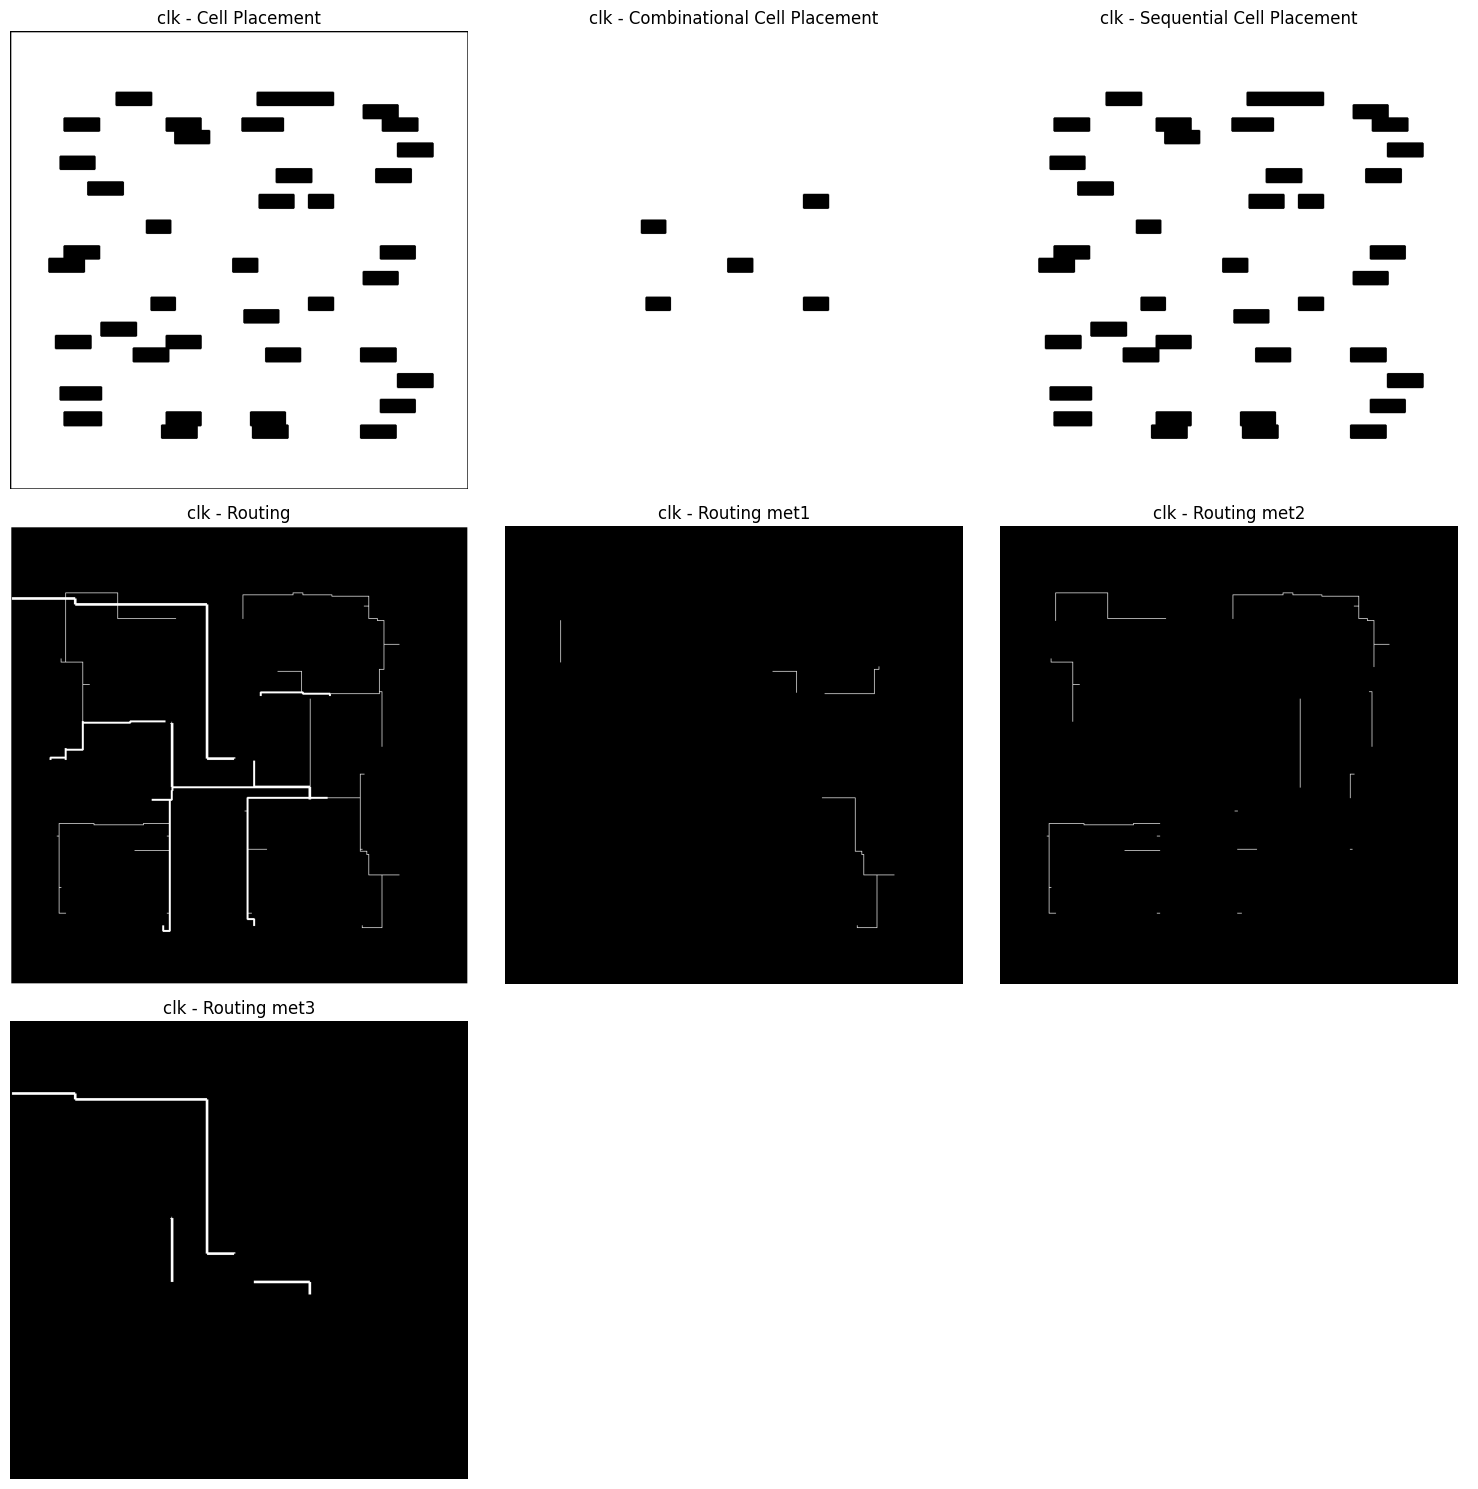

  Visualized 7 clock tree image(s)


In [28]:
print("=== Clock Trees ===")
print(f"Number of clock trees: {len(netlist.clock_trees)}")

# Process each clock tree
for clock_name, clock_tree in netlist.clock_trees.items():
    print(f"\nClock: {clock_name}")
    print(f"  Source: {clock_tree.clock_source}")
    print(f"  Number of buffers: {clock_tree.no_of_buffers}")
    print(f"  Number of clock sinks: {clock_tree.no_of_clock_sinks}")
    print(f"  Graph nodes: {len(clock_tree.nodes)}")
    print(f"  Graph edges: {len(clock_tree.edges)}")
    
    # Collect all available clock tree images
    clock_image_configs = [
        ('cell_placement', 'Cell Placement'),
        ('cell_placement_combinational', 'Combinational Cell Placement'),
        ('cell_placement_sequential', 'Sequential Cell Placement'),
        ('pin_placement', 'Pin Placement'),
        ('routing', 'Routing'),
    ]
    
    available_images = []
    for attr, title in clock_image_configs:
        if hasattr(clock_tree, attr):
            img = getattr(clock_tree, attr)
            if img is not None:
                available_images.append((attr, f'{clock_name} - {title}', img))
    
    # Add routing_by_metal layers
    if clock_tree.routing_by_metal:
        for metal_layer, routing_img in clock_tree.routing_by_metal.items():
            if routing_img is not None:
                available_images.append((f'routing_by_metal[{metal_layer}]', 
                                        f'{clock_name} - Routing {metal_layer}', routing_img))
    
    # Visualize clock tree images
    if available_images:
        print(f"  Available images: {len(available_images)}")
        n_images = len(available_images)
        cols = 3
        rows = (n_images + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
        
        # Ensure axes is always a flat numpy array we can index
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])
        else:
            axes = axes.flatten()
        
        for idx, (attr, title, img) in enumerate(available_images):
            ax = axes[idx]
            if 'placement' in attr.lower():
                img.plot(ax=ax, title=title, invert_mask=True)
            else:
                img.plot(ax=ax, title=title)
        
        # Hide unused subplots
        for i in range(n_images, len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
        print(f"  Visualized {n_images} clock tree image(s)")
    else:
        print("  No images available for this clock tree")


### Power Delivery Network (PDN)

The Power Delivery Network (PDN) represents the physical and electrical network responsible for distributing power across the chip. It captures the structure of the power grid through metal routing information for supply and ground networks (VDD and VSS).

**PDN Image Types:**

**Physical Routing Images (Binary Maps):**
- `routing_vdd`: VDD (power) routing image
- `routing_vss`: VSS (ground) routing image

**Analysis Heatmaps (Scalar Maps):**
- `ir_drop_vdd`: IR-drop analysis for VDD (voltage drop due to current flow)
- `ir_drop_vss`: IR-drop analysis for VSS
- `em_vdd`: Electromigration (EM) analysis for VDD (current density)
- `em_vss`: Electromigration analysis for VSS

**Image Resolution:**
- **Physical routing images**: Use binary spatial maps with resolution (L/λ, W/λ), same as netlist images, where each pixel corresponds to a square region with side length λ (minimum width of metal 1).
- **Analysis heatmaps**: Use scalar-valued maps with resolution (L/(kλ), W/(kλ)), where k is a downsampling factor (typically k=50). Each pixel corresponds to a k×λ by k×λ physical region, reflecting the sampling granularity of PDNSim analysis while preserving spatial correspondence with the underlying design.


=== Power Delivery Network ===
  routing_vdd: VDD Routing (shape: (695, 695))
  routing_vss: VSS Routing (shape: (695, 695))
  ir_drop_vdd: VDD IR Drop (shape: (14, 14))
  ir_drop_vss: VSS IR Drop (shape: (14, 14))
  em_vdd: VDD Electromigration (shape: (14, 14))
  em_vss: VSS Electromigration (shape: (14, 14))


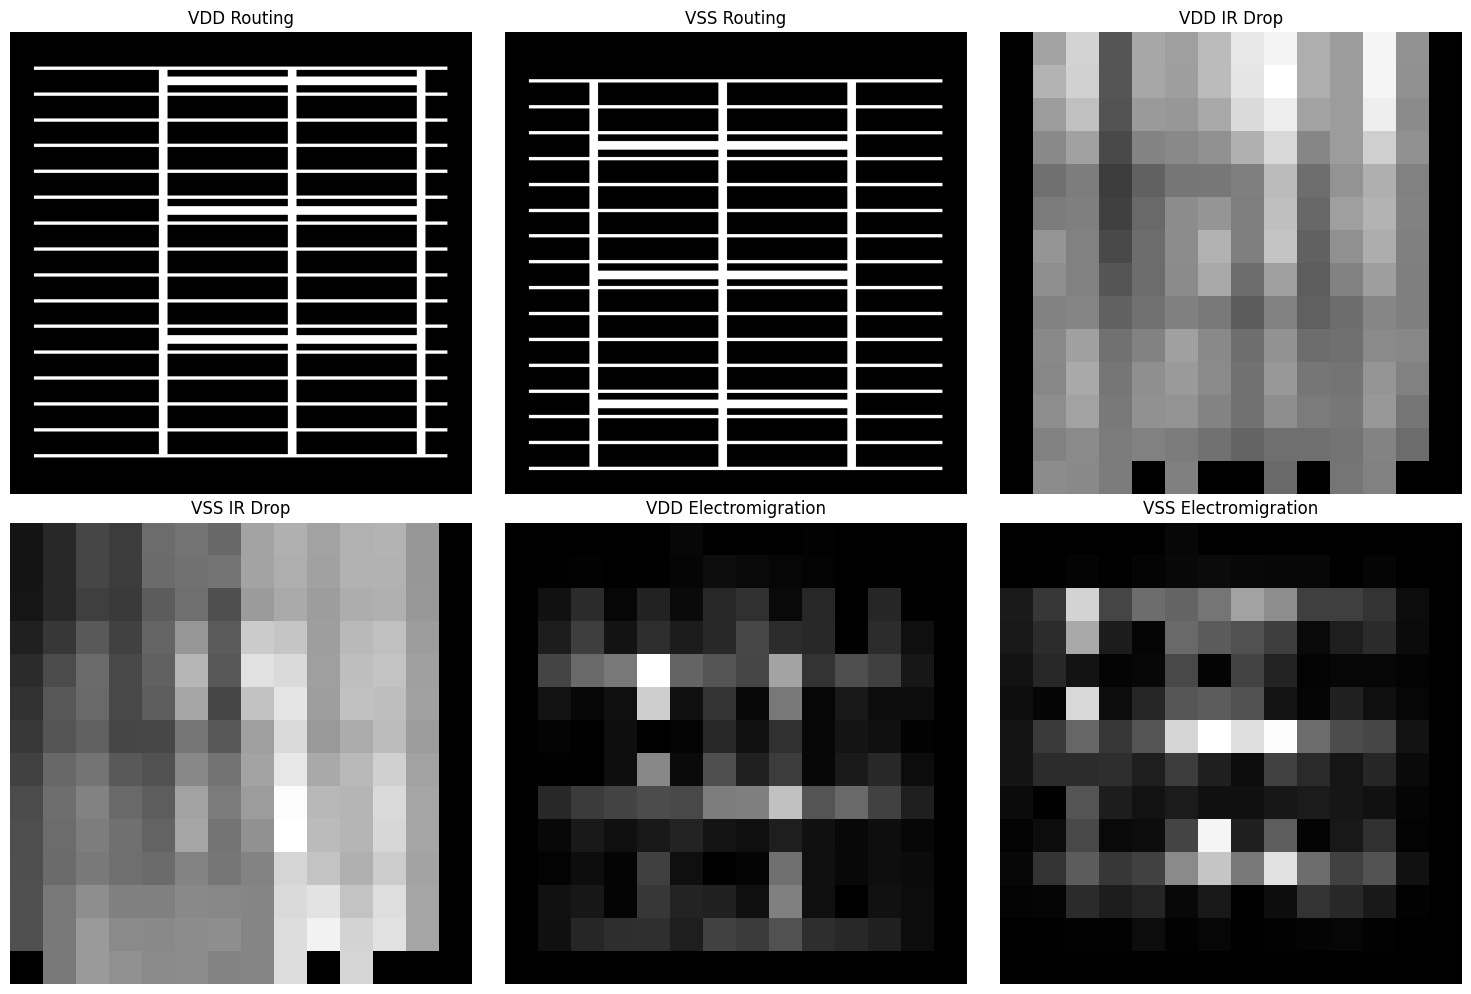


Visualized 6 PDN image(s)


In [29]:
pdn = netlist.power_delivery_network
print("=== Power Delivery Network ===")

# Collect all available PDN images
pdn_fields = [
    ('routing_vdd', 'VDD Routing'),
    ('routing_vss', 'VSS Routing'),
    ('ir_drop_vdd', 'VDD IR Drop'),
    ('ir_drop_vss', 'VSS IR Drop'),
    ('em_vdd', 'VDD Electromigration'),
    ('em_vss', 'VSS Electromigration'),
]

available_images = []
for attr, title in pdn_fields:
    if hasattr(pdn, attr):
        img = getattr(pdn, attr)
        if img is not None:
            available_images.append((attr, title, img))
            print(f"  {attr}: {title} (shape: {img.shape})")
        else:
            print(f"  {attr}: Not available")
    else:
        print(f"  {attr}: Not available")

# Visualize all available PDN images
if available_images:
    n_images = len(available_images)
    cols = 3
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    # Ensure axes is always a flat numpy array we can index
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    for idx, (attr, title, img) in enumerate(available_images):
        ax = axes[idx]
        img.plot(ax=ax, title=title)
    
    # Hide unused subplots
    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nVisualized {n_images} PDN image(s)")
else:
    print("\nNo PDN images available")

### Working with Graph and Tabular Data

EDA-schema provides flexibility in working with both graph and tabular data formats. Graph entities are ideal for graph operations like traversals, while tabular data is beneficial for relational operations such as joins, groups, and filters. All entity attributes are available in both graph and tabular formats, allowing for efficient data manipulation and analysis.

#### Accessing Tabular Data

Entity attributes can be accessed in a tabular format using the `get_table_data` method from the database backend. This returns pandas DataFrames that can be filtered, grouped, and analyzed using standard pandas operations.


In [30]:
# Access design constraints
constraints = dataset.db.get_entity("constraints", flow_id=flow_id)
print("=== Design Constraints ===")
print(f"Clock period: {constraints.clock_period} ns" if constraints.clock_period is not None else "Clock period: Not specified")
print(f"Clock uncertainty: {constraints.clock_uncertainty} ns" if constraints.clock_uncertainty is not None else "Clock uncertainty: Not specified")
print(f"Clock latency: {constraints.clock_latency} ns" if constraints.clock_latency is not None else "Clock latency: Not specified")
print(f"Clock transition: {constraints.clock_transition} ns" if constraints.clock_transition is not None else "Clock transition: Not specified")
print(f"Input delay: {constraints.input_delay} ns" if constraints.input_delay is not None else "Input delay: Not specified")
print(f"Output delay: {constraints.output_delay} ns" if constraints.output_delay is not None else "Output delay: Not specified")
print(f"Aspect ratio: {constraints.aspect_ratio}" if constraints.aspect_ratio is not None else "Aspect ratio: Not specified")
print(f"Core utilization: {constraints.core_utilization}%" if constraints.core_utilization is not None else "Core utilization: Not specified")

=== Design Constraints ===
Clock period: 3.0 ns
Clock uncertainty: 0.05 ns
Clock latency: 0.03 ns
Clock transition: 0.02 ns
Input delay: 0.03 ns
Output delay: 0.03 ns
Aspect ratio: 1.0
Core utilization: 0.3%


In [31]:
# Filtering netlists data by flow_id and stage
netlists_filtered = dataset.db.get_table_data("netlists", flow_id=flow_id, stage="detailed_route")
print(f"Found {len(netlists_filtered)} netlist(s) for flow '{flow_id}' at 'detailed_route' stage")
netlists_filtered.head()

Found 1 netlist(s) for flow 'gcd-000001' at 'detailed_route' stage


,flow_id,stage,no_of_inputs,no_of_outputs,no_of_cells,no_of_nets,no_of_pins,utilization,width,height
0,gcd-000001,detailed_route,36,18,1105,413,1081,0.98,97.34,97.34


In [32]:
# Filtering netlists data by stage
netlists_route_data = dataset.db.get_table_data("netlists", stage="detailed_route")
print(f"Found {len(netlists_route_data)} netlist(s) at 'detailed_route' stage")
netlists_route_data.head()

Found 1 netlist(s) at 'detailed_route' stage


,flow_id,stage,no_of_inputs,no_of_outputs,no_of_cells,no_of_nets,no_of_pins,utilization,width,height
0,gcd-000001,detailed_route,36,18,1105,413,1081,0.98,97.34,97.34


In [33]:

# Filtering by flow_id and stage
netlists_filtered = dataset.db.get_table_data("netlists", flow_id=flow_id, stage="detailed_route")
print(f"\nFound {len(netlists_filtered)} netlist(s) for flow '{flow_id}' at 'detailed_route' stage")
netlists_filtered.head()


Found 1 netlist(s) for flow 'gcd-000001' at 'detailed_route' stage


,flow_id,stage,no_of_inputs,no_of_outputs,no_of_cells,no_of_nets,no_of_pins,utilization,width,height
0,gcd-000001,detailed_route,36,18,1105,413,1081,0.98,97.34,97.34


#### Accessing Graph Data

Graph entities (Netlist, ClockTree, TimingPath) can be accessed and traversed using their graph structure. The graph contains nodes and edges that represent circuit connectivity.


In [34]:
# Access graph data from netlist
print("=== Netlist Graph Structure ===")
print(f"Total nodes: {len(netlist.nodes)}")
print(f"Total edges: {len(netlist.edges)}")

# Count nodes by type
node_types = {}
for node_id, node_data in netlist.nodes.items():
    node_type = node_data.get('type', 'UNKNOWN')
    node_types[node_type] = node_types.get(node_type, 0) + 1

print("\nNodes by type:")
for node_type, count in sorted(node_types.items()):
    print(f"  {node_type}: {count}")

# Example: Traverse graph from a gate to its connected nets
if netlist.nodes:
    # Get first gate node
    for node_id, node_data in list(netlist.nodes.items())[:10]:
        if node_data.get('type') == 'GATE':
            print(f"\n=== Gate: {node_id} ===")
            # Get connected edges
            connected_edges = [e for e in netlist.edges if e[0] == node_id or e[1] == node_id]
            print(f"  Connected to {len(connected_edges)} edges")
            # Show first few connections
            for edge in connected_edges[:3]:
                print(f"    {edge[0]} -> {edge[1]}")
            break


=== Netlist Graph Structure ===
Total nodes: 2653
Total edges: 2216

Nodes by type:
  GATE: 1105
  NET: 413
  PIN: 1081
  PORT: 54


#### Accessing Image Data

Image2D objects can be accessed from various entities (netlist, routability metrics, PDN, clock trees) and converted to NumPy arrays for custom analysis or visualization.


In [35]:
# Access Image2D data as NumPy arrays
print("=== Image Data Access ===")

# Example 1: Netlist cell placement
placement_array = netlist.cell_placement
print(f"Cell placement image:")
print(f"  Shape: {placement_array.shape}")
print(f"  Dtype: {placement_array.dtype}")
print(f"  Number of placed cells: {placement_array.sum()}")

# Example 2: Routability metrics
rudy_array = design_stage.routability_metrics.rudy_net
print(f"\nRUDY net congestion image:")
print(f"  Shape: {rudy_array.shape}")
print(f"  Dtype: {rudy_array.dtype}")
print(f"  Min value: {rudy_array.min():.4f}")
print(f"  Max value: {rudy_array.max():.4f}")
print(f"  Mean value: {rudy_array.mean():.4f}")

# Example 3: Custom analysis on image data
placement_array = netlist.cell_placement
# Calculate cell density per region
print(f"\n=== Custom Image Analysis ===")
print(f"Cell density: {placement_array.mean():.2%}")
print(f"Regions with cells: {(placement_array > 0).sum()} / {placement_array.size}")

=== Image Data Access ===
Cell placement image:
  Shape: (695, 695)
  Dtype: uint8
  Number of placed cells: 381071

RUDY net congestion image:
  Shape: (14, 14)
  Dtype: float64
  Min value: 0.0000
  Max value: 275.6983
  Mean value: 136.6182

=== Custom Image Analysis ===
Cell density: 78.89%
Regions with cells: 381071 / 483025


## Summary

Congratulations! You've completed the Getting Started tutorial. You've learned:

1. How to set up EDA-Schema and load datasets
2. How to load and inspect netlists
3. How to access entity data (ports, gates, nets, pins)
4. How to access design metrics (area, power, timing, cell metrics)
5. How to access routability metrics and RUDY congestion images
6. How to work with timing arcs (NetArc and CellArc)
7. How to access clock trees and power delivery networks
8. How to access design constraints
9. How to visualize Image2D data (placement, routing, congestion)
10. How to query tabular data from the database